**RoadNet-CA Runtime Testing on Greedy_SOSP**

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from Greedy_SOSP import Greedy_SOSP

DATA_PATH = Path("data") / "roadNet-CA.txt"
RESULTS_GSOSP_CSV = Path("roadNet-CA_results_GSOSP.csv")

In [6]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 5,533,214 edges from data\roadNet-CA.txt


In [3]:
EDGE_COUNTS = [50_000, 100_000, 200_000, 400_000, 800_000, 1_600_000, 3_200_000, len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Greedy_SOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 40/40 [02:58<00:00,  4.46s/it]


,edges,nodes,runtime,trial
0,50000,17572,0.036852,1
1,50000,17572,0.038259,2
2,50000,17572,0.036158,3
3,50000,17572,0.041464,4
4,50000,17572,0.029763,5


In [4]:
results_df.to_csv(RESULTS_GSOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_GSOSP_CSV}")

Saved runtime results to roadNet-CA_results_GSOSP.csv


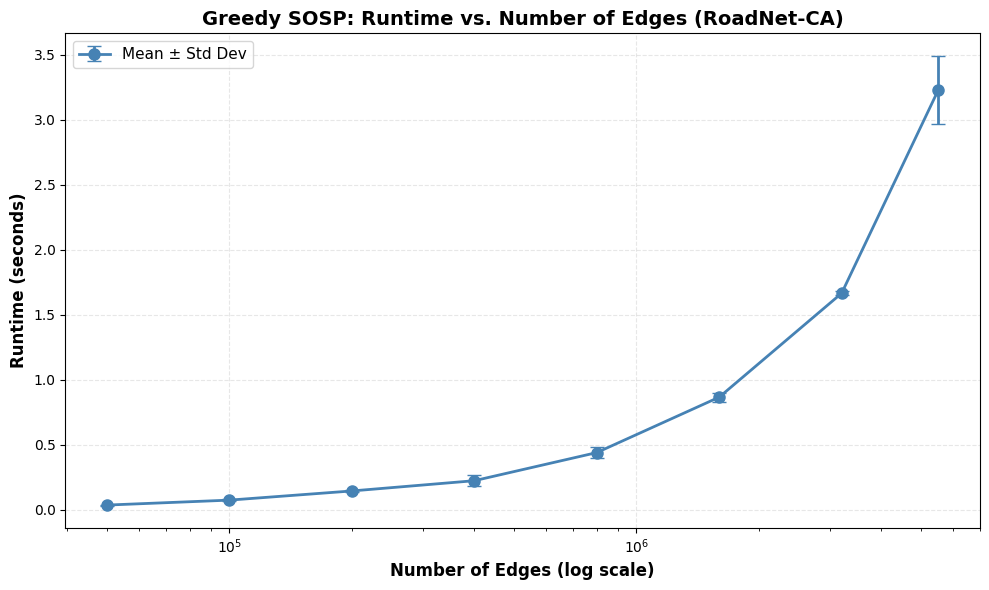


Runtime Statistics by Edges:
  edges     mean      std
  50000 0.036499 0.004282
 100000 0.074564 0.008376
 200000 0.145111 0.005609
 400000 0.223957 0.041676
 800000 0.440359 0.043884
1600000 0.866924 0.034803
3200000 1.666730 0.016960
5533214 3.232548 0.260852


In [5]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Greedy SOSP: Runtime vs. Number of Edges (RoadNet-CA)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

**RoadNet-CA Runtime Testing on Robust_MOSP**

In [6]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from Robust_MOSP import  Robust_MOSP

DATA_PATH = Path("data") / "roadNet-CA.txt"
RESULTS_RMOSP_CSV = Path("roadNet-CA_results_RMOSP.csv")

In [7]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 5,533,214 edges from data\roadNet-CA.txt


In [8]:
EDGE_COUNTS = [50_000, 100_000, 200_000, 400_000, 800_000, 1_600_000, 3_200_000, len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Robust_MOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 40/40 [1:45:02<00:00, 157.55s/it]


,edges,nodes,runtime,trial
0,50000,17572,5.054544,1
1,50000,17572,4.311660,2
2,50000,17572,4.409652,3
3,50000,17572,4.477172,4
4,50000,17572,4.572127,5


In [9]:
results_df.to_csv(RESULTS_RMOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_RMOSP_CSV}")

Saved runtime results to roadNet-CA_results_RMOSP.csv


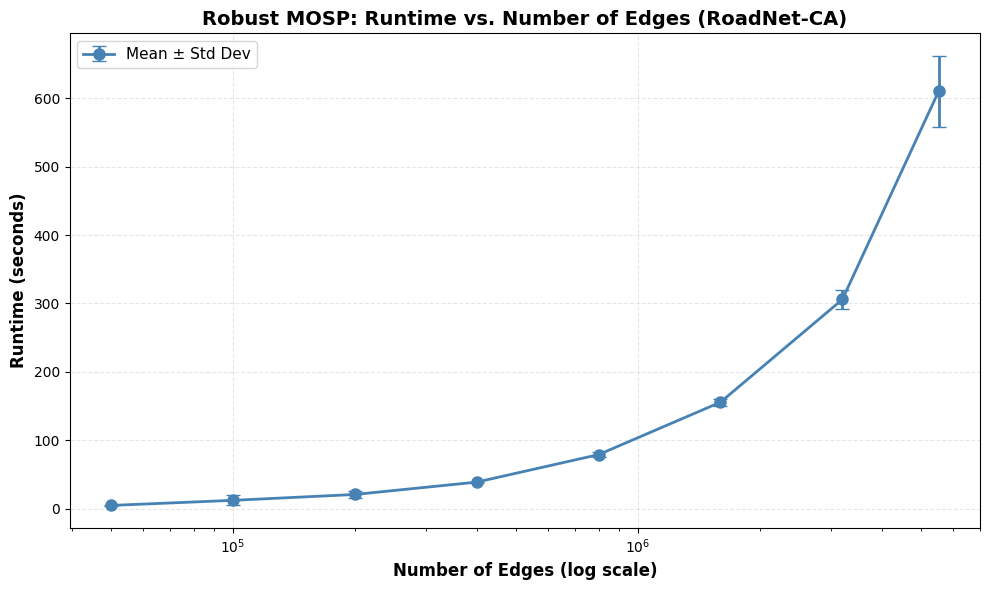


Runtime Statistics by Edges:
  edges       mean       std
  50000   4.565031  0.289712
 100000  12.017646  7.284161
 200000  20.596648  4.811784
 400000  38.681765  0.880054
 800000  78.891484  3.131095
1600000 155.559141  5.310029
3200000 305.846280 14.240310
5533214 610.382330 51.928918


In [10]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Robust MOSP: Runtime vs. Number of Edges (RoadNet-CA)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

**combined greedy sosp and robust mosp**

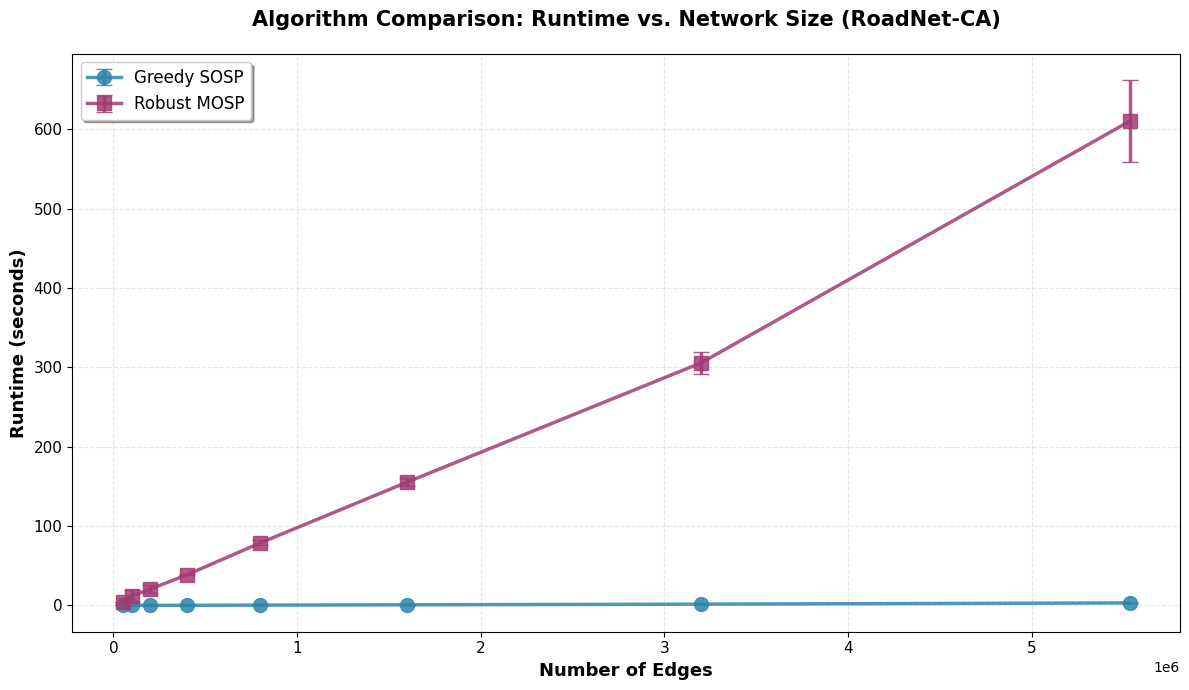

COMBINED ALGORITHM COMPARISON - RoadNet-CA

Greedy SOSP Runtime Statistics:
  edges     mean      std
  50000 0.036499 0.004282
 100000 0.074564 0.008376
 200000 0.145111 0.005609
 400000 0.223957 0.041676
 800000 0.440359 0.043884
1600000 0.866924 0.034803
3200000 1.666730 0.016960
5533214 3.232548 0.260852

Robust MOSP Runtime Statistics:
  edges       mean       std
  50000   4.565031  0.289712
 100000  12.017646  7.284161
 200000  20.596648  4.811784
 400000  38.681765  0.880054
 800000  78.891484  3.131095
1600000 155.559141  5.310029
3200000 305.846280 14.240310
5533214 610.382330 51.928918

SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):
Edges:  50000 | Speedup:   125.07x
Edges: 100000 | Speedup:   161.17x
Edges: 200000 | Speedup:   141.94x
Edges: 400000 | Speedup:   172.72x
Edges: 800000 | Speedup:   179.15x
Edges: 1600000 | Speedup:   179.44x
Edges: 3200000 | Speedup:   183.50x
Edges: 5533214 | Speedup:   188.82x


In [11]:
# Combined plot: Greedy SOSP vs Robust MOSP on RoadNet-CA
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths
RESULTS_GSOSP_CSV = Path("roadNet-CA_results_GSOSP.csv")
RESULTS_RMOSP_CSV = Path("roadNet-CA_results_RMOSP.csv")

# Load results from both algorithms
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)
rmosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
gsosp_runtime = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
gsosp_runtime['algorithm'] = 'Greedy SOSP'

rmosp_runtime = rmosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
rmosp_runtime['algorithm'] = 'Robust MOSP'

# Create the combined plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Greedy SOSP
ax.errorbar(gsosp_runtime['edges'], gsosp_runtime['mean'], 
            yerr=gsosp_runtime['std'], marker='o', linewidth=2.5, 
            markersize=10, capsize=6, label='Greedy SOSP', 
            color='#2E86AB', alpha=0.85)

# Plot Robust MOSP
ax.errorbar(rmosp_runtime['edges'], rmosp_runtime['mean'], 
            yerr=rmosp_runtime['std'], marker='s', linewidth=2.5, 
            markersize=10, capsize=6, label='Robust MOSP', 
            color='#A23B72', alpha=0.85)

# Formatting for research paper
ax.set_xlabel('Number of Edges', fontsize=13, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Algorithm Comparison: Runtime vs. Network Size (RoadNet-CA)', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)

# Add tick formatting
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
# plt.savefig('roadNet-CA_combined_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison statistics
print("=" * 70)
print("COMBINED ALGORITHM COMPARISON - RoadNet-CA")
print("=" * 70)
print("\nGreedy SOSP Runtime Statistics:")
print(gsosp_runtime[['edges', 'mean', 'std']].to_string(index=False))
print("\nRobust MOSP Runtime Statistics:")
print(rmosp_runtime[['edges', 'mean', 'std']].to_string(index=False))

# Calculate speedup
print("\n" + "=" * 70)
print("SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):")
print("=" * 70)
for edges in gsosp_runtime['edges']:
    gsosp_mean = gsosp_runtime[gsosp_runtime['edges'] == edges]['mean'].values[0]
    rmosp_mean = rmosp_runtime[rmosp_runtime['edges'] == edges]['mean'].values[0]
    speedup = rmosp_mean / gsosp_mean
    print(f"Edges: {edges:>6} | Speedup: {speedup:>8.2f}x")